In [12]:
from collections import Counter
import math, urllib.request

url = ("https://raw.githubusercontent.com/HaykTarkhanyan/"
       "python_math_ml_course/main/math/assets/panir_hy.txt")
text = urllib.request.urlopen(url).read().decode("utf-8")

print(text[:1000])

Պանիրը կաթից ստացվող կաթնամթերք է, որը արտադրվում է համային տեսականիներով, հյուսվածքներով և ձևերով` կաթնային սպիտակուցային պրազեինների կոագուլյացիայի միջոցով։ Այն պարունակում է սպիտակուցներ և ճարպեր, սովորաբար պատրաստվում է կովերի, գոմեշների, այծերի կամ ոչխարների կաթից։ Արտադրության ընթացքում կաթը սովորաբար թթվեցնում են, և հավելում ֆերմենտային շիճուկով, վերջինս էլ առաջացնում է կոագուլյացիա։ Պինդ նյութերը բաժանվում և սեղմվում են ընդունելով վերջնական տեսք։ Որոշ պանիրներ ունեն բորբոսային շեր կեղևի, արտաքին շերտի կամ ամբողջ հատվածներում։ Պանիրների մեծ մասը հալվում են ճաշ պատրաստելու ջերմաստիճանում։
Ավելի քան հազար տեսակի պանիր գոյություն ունի և ներկայումս էլ արտադրվում է տարբեր երկրներում։ Դրանց ոճերը, հյուսվածքները և բույրերը կախված են կաթի ծագումից (ներառյալ կենդանու սննդակարգը), պաստորիզացումից, յուղայնության պարունակությունից, բակտերիաներից և բորբոսից, և թե ինչքան ժամանակ է վերամշակման փուլում գտնվել։ Խոտաբույսերը, համեմունքները կամ փայտի ծուխը կարող են օգտագործվել որպես բուրավետիչ նյո

In [13]:

def is_armenian(ch):  # U+0531–U+0556 upper, U+0561–U+0587 lower
    o = ord(ch)
    return 0x0531 <= o <= 0x0556 or 0x0561 <= o <= 0x0587

print(is_armenian("ա"), is_armenian("Ա"), is_armenian("a"))


True True False


[('ա', 3519), ('ն', 2232), ('ր', 1808), ('ո', 1706), ('ե', 1362), ('ի', 1352), ('մ', 967), ('ւ', 927), ('կ', 772), ('տ', 675)]


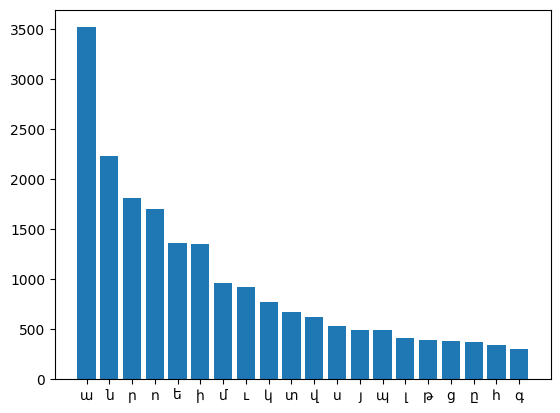

In [15]:

letters = [c for c in text.lower() if is_armenian(c)]

counts = Counter(letters)

print(counts.most_common(10))

# plot the distribution
import matplotlib.pyplot as plt
plt.bar(*zip(*counts.most_common(20)))
plt.show()

In [17]:

n = len(letters)
n

22417

In [18]:


H = -sum((c / n) * math.log2(c / n) for c in counts.values())
print(f"{n} letters, {len(counts)} distinct")
print(f"empirical entropy = {H:.3f} bits/letter")

22417 letters, 39 distinct
empirical entropy = 4.484 bits/letter


#  Wordle

In [20]:
import urllib.request
url = ("https://gist.githubusercontent.com/cfreshman/"
       "a03ef2cba789d8cf00c08f767e0fad7b/raw/wordle-answers-alphabetical.txt")
words = urllib.request.urlopen(url).read().decode().split()
assert len(words) == 2315

words[:10]

['aback',
 'abase',
 'abate',
 'abbey',
 'abbot',
 'abhor',
 'abide',
 'abled',
 'abode',
 'abort']

In [21]:
def feedback(guess, answer):
    res = ['.'] * 5
    pool = Counter(answer)
    for i in range(5):                       # greens first
        if guess[i] == answer[i]:
            res[i] = 'G'; pool[guess[i]] -= 1
    for i in range(5):                       # then yellows from what's left
        if res[i] == '.' and pool[guess[i]] > 0:
            res[i] = 'Y'; pool[guess[i]] -= 1
    return tuple(res)

In [ ]:
from collections import Counter
import math

def feedback(guess, answer):
    res = ['.'] * 5
    pool = Counter(answer)
    for i in range(5):                       # greens first
        if guess[i] == answer[i]:
            res[i] = 'G'; pool[guess[i]] -= 1
    for i in range(5):                       # then yellows from what's left
        if res[i] == '.' and pool[guess[i]] > 0:
            res[i] = 'Y'; pool[guess[i]] -= 1
    return tuple(res)


RAISE 5.88 bits
SLATE 5.86 bits
CRATE 5.83 bits
IRATE 5.83 bits
TRACE 5.83 bits


In [22]:
print(feedback("chess", "chees"))

('G', 'G', 'G', '.', 'G')


In [23]:

def expected_info(guess, candidates):
    counts = Counter(feedback(guess, a) for a in candidates)
    n = len(candidates)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())


In [24]:

best = sorted(words, key=lambda g: expected_info(g, words), reverse=True)[:5]
for g in best:
    print(g.upper(), round(expected_info(g, words), 2), "bits")

RAISE 5.88 bits
SLATE 5.86 bits
CRATE 5.83 bits
IRATE 5.83 bits
TRACE 5.83 bits


In [25]:
ans = open("../../assets/bardle_hy_5_answers.txt", encoding="utf-8").read().split()
guesses = open("../../assets/bardle_hy_5_guesses.txt", encoding="utf-8").read().split()

best = sorted(guesses, key=lambda g: expected_info(g, ans), reverse=True)[:3]

In [11]:
best

['կարեն', 'նոտար', 'կարին']